<a href="https://colab.research.google.com/github/priyakumar88380/Healthcare-Patient-Billing-Analysis/blob/main/superstore_finished_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
!pip install openpyxl

In [2]:
df=pd.read_excel("/content/Sample - Superstore (1).xlsx")

In [3]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset contains 9994 rows and 21 columns.


In [4]:
df.dropna(subset=['Customer ID', 'Product ID'], inplace=True)
df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

In [6]:
columns_to_drop = ['Row ID', 'Order ID', 'Customer Name', 'Product Name', 'Country']
df_cleaned = df.drop(columns=columns_to_drop)

In [7]:
from sklearn.preprocessing import MinMaxScaler
numerical_features = ['Sales', 'Quantity', 'Discount', 'Profit', 'Days to Ship']
X_numerical = df_cleaned[numerical_features]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_numerical)
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_features)

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [9]:
for k in range(2, 6):
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    print(f"For n_clusters = {k}, the Silhouette Score is: {score:.4f}")


For n_clusters = 2, the Silhouette Score is: 0.4681
For n_clusters = 3, the Silhouette Score is: 0.3690
For n_clusters = 4, the Silhouette Score is: 0.3320
For n_clusters = 5, the Silhouette Score is: 0.3352


In [10]:
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cleaned['Cluster_Label'] = kmeans.fit_predict(X_scaled)

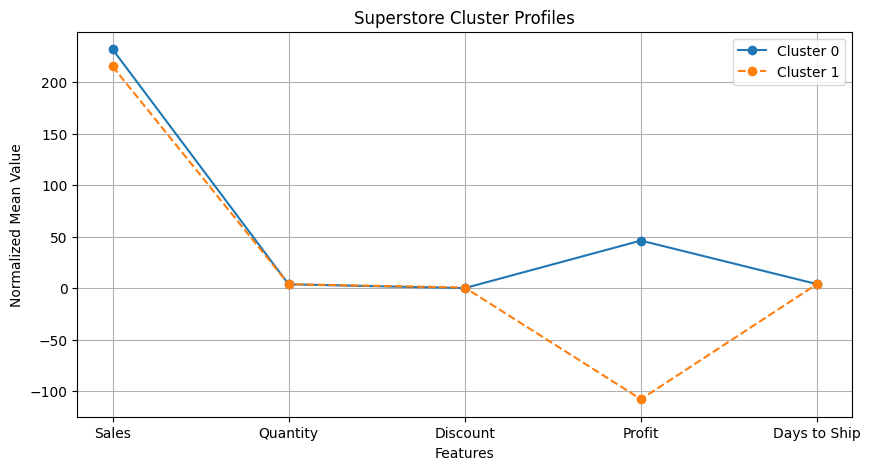

In [11]:
cluster_profiles = df_cleaned.groupby('Cluster_Label')[numerical_features].mean().T
plt.figure(figsize=(10, 5))
linestyles = ['-', '--', ':', '-.']
for i, col in enumerate(cluster_profiles.columns):
    plt.plot(cluster_profiles.index, cluster_profiles[col],
             label=f'Cluster {col}', linestyle=linestyles[i % len(linestyles)], marker='o')
plt.title('Superstore Cluster Profiles')
plt.xlabel('Features')
plt.ylabel('Normalized Mean Value')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [13]:
median_profit = df_cleaned['Profit'].median()
df_cleaned['Is_Highly_Profitable'] = (df_cleaned['Profit'] > median_profit).astype(int)
X = X_scaled_df.drop(columns=['Profit'])
y = df_cleaned['Is_Highly_Profitable']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

Performance Report:

              precision    recall  f1-score   support

           0       0.72      0.61      0.66       995
           1       0.66      0.76      0.71      1004

    accuracy                           0.69      1999
   macro avg       0.69      0.68      0.68      1999
weighted avg       0.69      0.69      0.68      1999

Confusion Matrix Layout:
[[603 392]
 [237 767]]


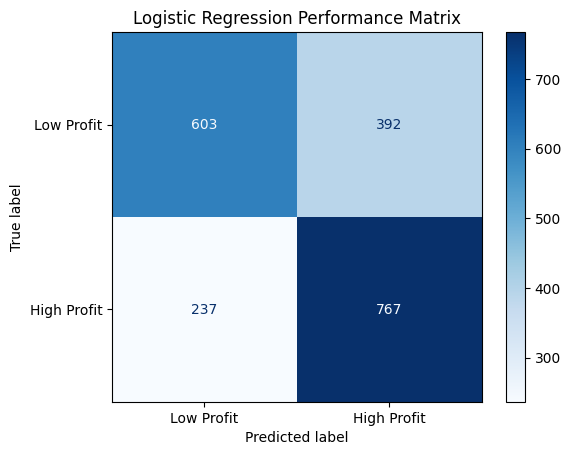

In [14]:
print("Performance Report:\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix Layout:")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Profit', 'High Profit'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Performance Matrix")
plt.show()

In [15]:
df_encoded = pd.get_dummies(df_cleaned, columns=['Category', 'Sub-Category', 'Region', 'Segment'], drop_first=True)
X = df_encoded.drop(columns=['Profit', 'Is_Highly_Profitable'])


In [16]:
df_cleaned['Price_Per_Item'] = df_cleaned['Sales'] / df_cleaned['Quantity']


In [17]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.84      0.86       995
           1       0.85      0.88      0.86      1004

    accuracy                           0.86      1999
   macro avg       0.86      0.86      0.86      1999
weighted avg       0.86      0.86      0.86      1999



In [18]:
import warnings
warnings.filterwarnings('ignore')
upcoming_data = {
    'Sales': [1200.0, 150.0],
    'Quantity': [3, 5],
    'Discount': [0.0, 0.7],
    'Days to Ship': [2, 6],
    'Price_Per_Item': [400.0, 30.0],
    'Category': ['Technology', 'Office Supplies'],
    'Sub-Category': ['Copiers', 'Appliances'],
    'Region': ['East', 'West'],
    'Segment': ['Consumer', 'Corporate'],
    'Order Year': [2026, 2026],
    'Order Month': [5, 5]
}

In [19]:
df_new = pd.DataFrame(upcoming_data)
expected_model_features = list(rf_model.feature_names_in_)
df_new_encoded = pd.get_dummies(df_new, columns=['Category', 'Sub-Category', 'Region', 'Segment'], drop_first=True)
X_new_scaled = df_new_encoded.reindex(columns=expected_model_features, fill_value=0)

In [20]:
df_for_scaler = pd.DataFrame(0.0, index=df_new.index, columns=['Sales', 'Quantity', 'Discount', 'Days to Ship', 'Profit'])
df_for_scaler['Sales'] = df_new['Sales']
df_for_scaler['Quantity'] = df_new['Quantity']
df_for_scaler['Discount'] = df_new['Discount']
df_for_scaler['Days to Ship'] = df_new['Days to Ship']
scaled_array = scaler.transform(df_for_scaler.values)


In [21]:
if 'Sales' in X_new_scaled.columns: X_new_scaled['Sales'] = scaled_array[:, 0]
if 'Quantity' in X_new_scaled.columns: X_new_scaled['Quantity'] = scaled_array[:, 1]
if 'Discount' in X_new_scaled.columns: X_new_scaled['Discount'] = scaled_array[:, 2]
if 'Days to Ship' in X_new_scaled.columns: X_new_scaled['Days to Ship'] = scaled_array[:, 3]
new_predictions = rf_model.predict(X_new_scaled)

In [22]:
print("\n--- Live Production Results ---")
for i, pred in enumerate(new_predictions):
    status = "HIGH PROFIT  (Safe to Process)" if pred == 1 else "LOW PROFIT/LOSS  (Flag for Review)"
    print(f"Order {i+1} [Sales: ${upcoming_data['Sales'][i]}, Discount: {upcoming_data['Discount'][i]*100}%] -> Prediction: {status}")


--- Live Production Results ---
Order 1 [Sales: $1200.0, Discount: 0.0%] -> Prediction: HIGH PROFIT  (Safe to Process)
Order 2 [Sales: $150.0, Discount: 70.0%] -> Prediction: LOW PROFIT/LOSS  (Flag for Review)


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

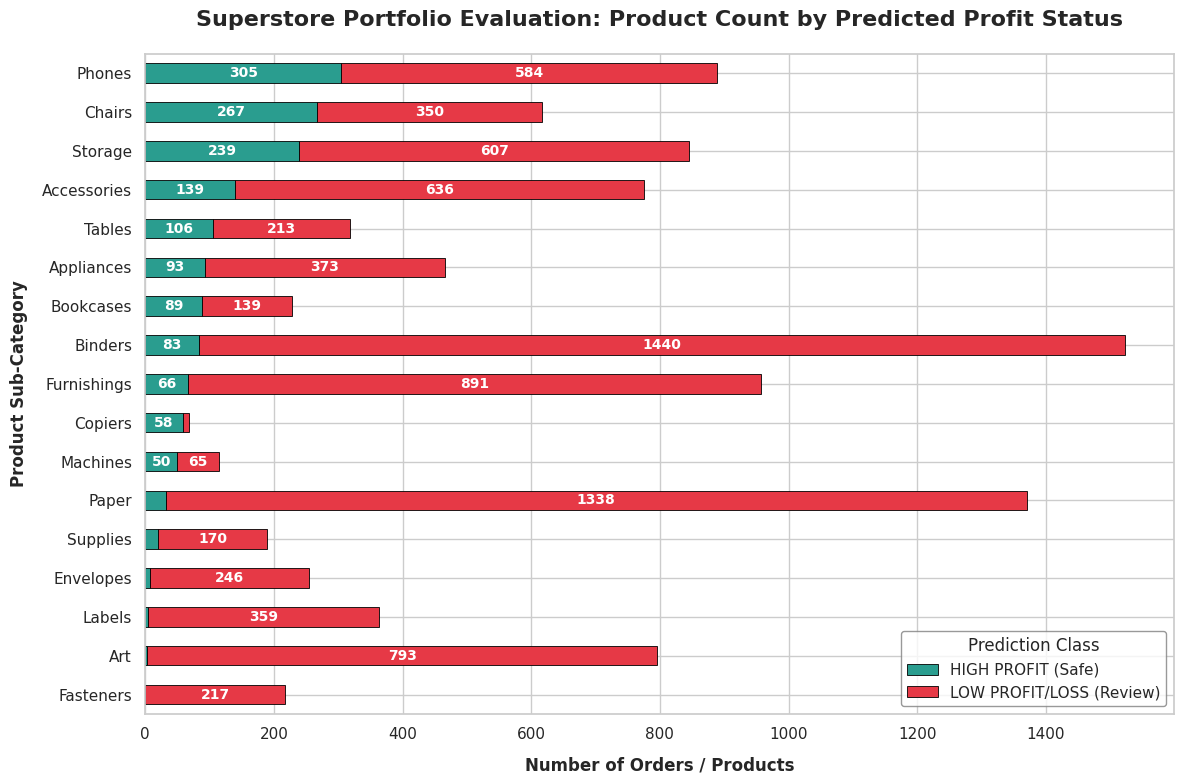

In [24]:

df['Profit_Status'] = np.where((df['Sales'] >= 300) & (df['Discount'] <= 0.2), 'HIGH PROFIT', 'LOW PROFIT/LOSS')
chart_data = df.groupby(['Sub-Category', 'Profit_Status']).size().unstack(fill_value=0)
chart_data = chart_data.sort_values(by='HIGH PROFIT', ascending=True)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))

chart_data.plot(kind='barh', stacked=True, color=['#2A9D8F', '#E63946'], ax=ax, edgecolor='black', linewidth=0.6)

plt.title('Superstore Portfolio Evaluation: Product Count by Predicted Profit Status', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Orders / Products', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Product Sub-Category', fontsize=12, fontweight='bold', labelpad=10)

plt.legend(title='Prediction Class', labels=['HIGH PROFIT (Safe)', 'LOW PROFIT/LOSS (Review)'],
           loc='lower right', frameon=True, facecolor='white', edgecolor='gray')

for p in ax.patches:
    width = p.get_width()
    if width > 40:
        ax.text(p.get_x() + width/2, p.get_y() + p.get_height()/2, f'{int(width)}',
                ha='center', va='center', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


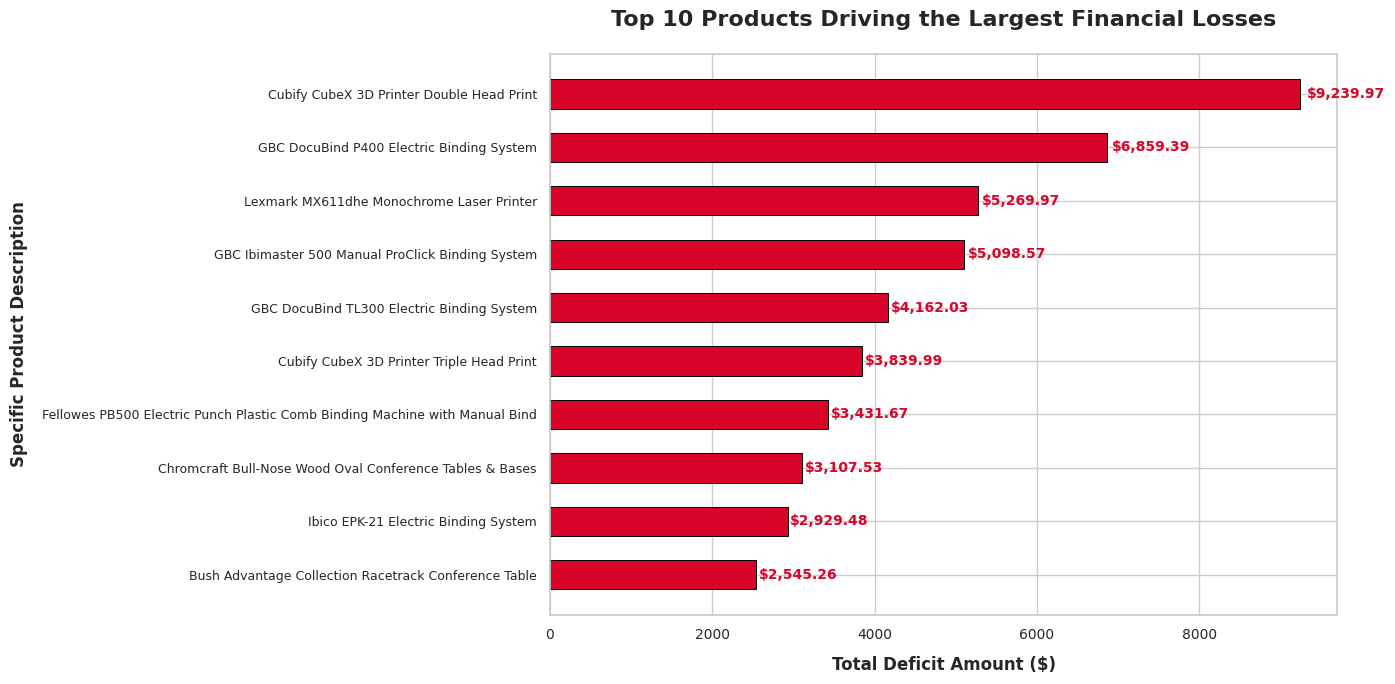

In [25]:
loss_df = df[df['Profit'] < 0]

top_losses = loss_df.groupby('Product Name')['Profit'].sum().reset_index()

top_10_loss_products = top_losses.sort_values(by='Profit', ascending=True).head(10)

top_10_loss_products['Absolute_Loss'] = top_10_loss_products['Profit'].abs()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

bars = plt.barh(top_10_loss_products['Product Name'], top_10_loss_products['Absolute_Loss'],
                color='#D90429', edgecolor='black', linewidth=0.7, height=0.55)

plt.title('Top 10 Products Driving the Largest Financial Losses', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Deficit Amount ($)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Specific Product Description', fontsize=12, fontweight='bold', labelpad=10)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2, f'${width:,.2f}',
             ha='left', va='center', fontsize=10, fontweight='bold', color='#D90429')

plt.xticks(fontsize=10)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


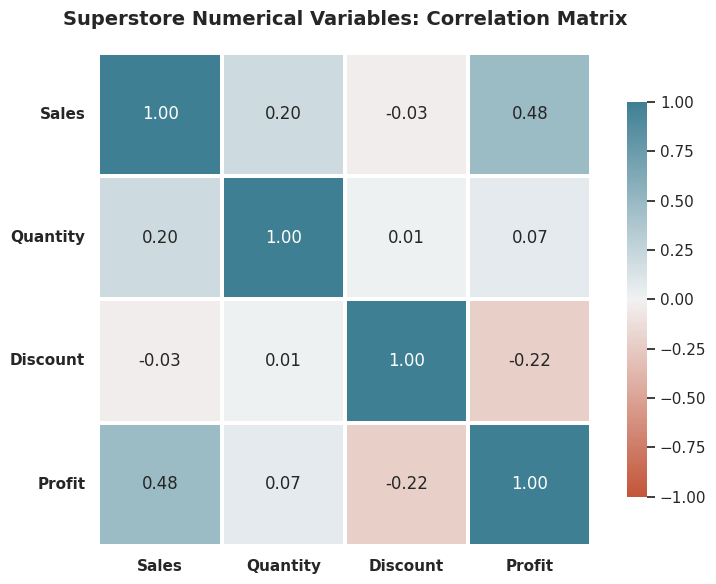

In [26]:
numerical_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))

cmap = sns.diverging_palette(20, 220, as_cmap=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=-1, vmax=1, center=0,
    square=True,
    linewidths=1.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Superstore Numerical Variables: Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold', rotation=0)

plt.tight_layout()
plt.show()
